In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,confusion_matrix

In [42]:
df=pd.read_csv("credit_card_fraud_10k.csv")
df=df.drop("transaction_id",axis=1)
df.isnull().sum()
df.describe()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


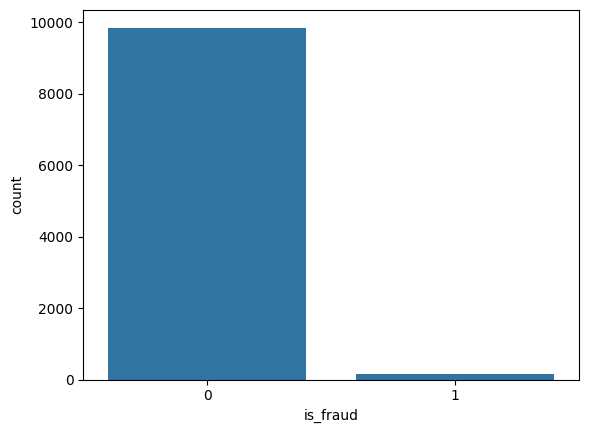

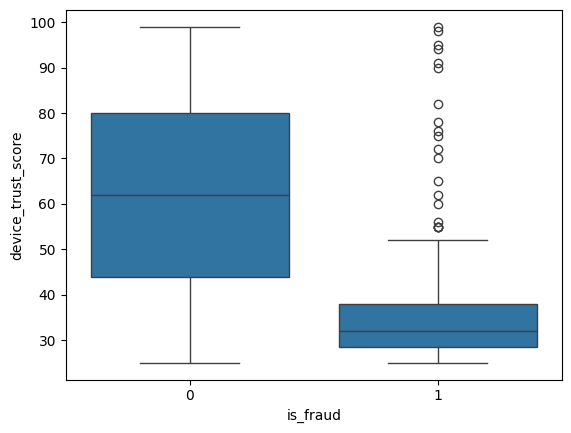

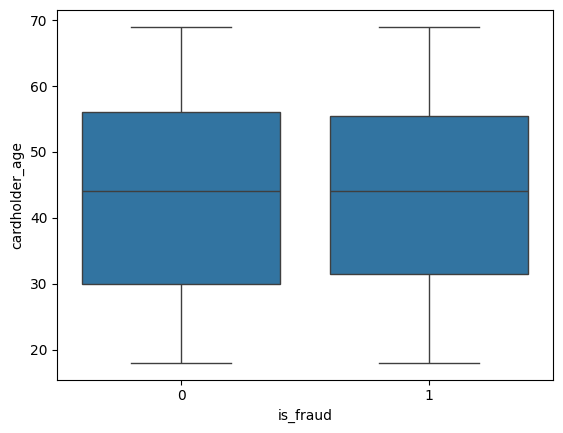

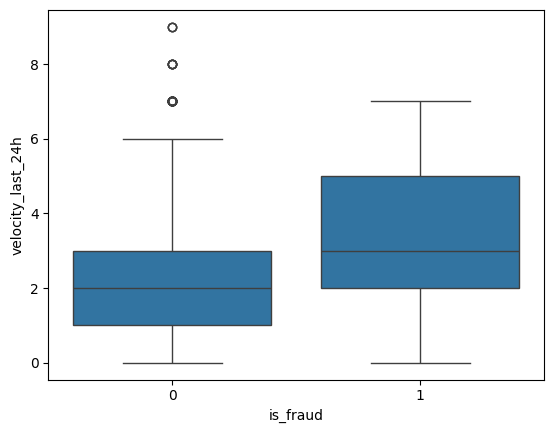

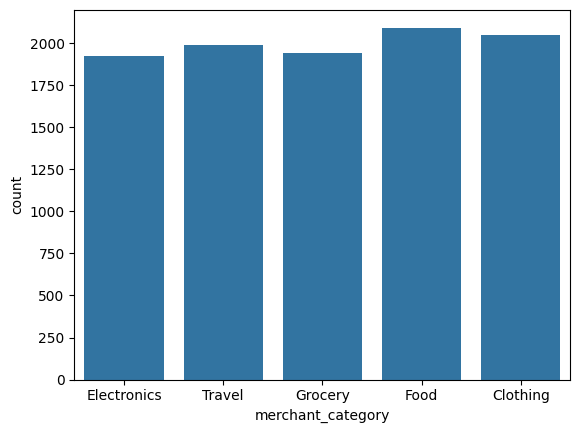

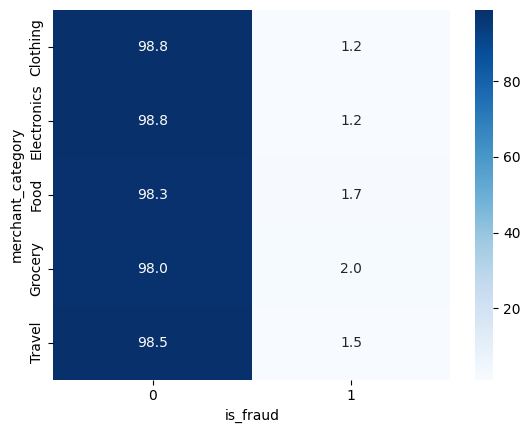

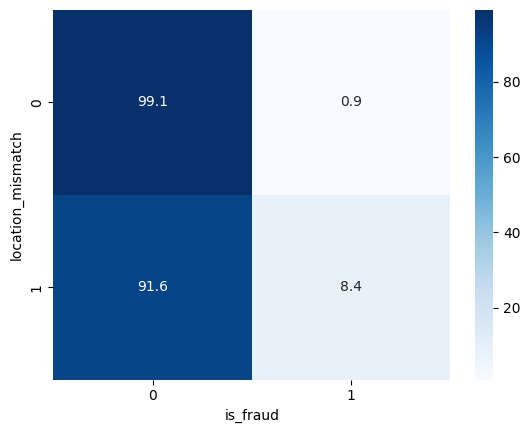

In [43]:
sns.countplot(data=df,x="is_fraud")
plt.show()
sns.boxplot(data=df,x="is_fraud",y="device_trust_score")
plt.show()
sns.boxplot(data=df,x="is_fraud",y="cardholder_age")
plt.show()
sns.boxplot(data=df,x="is_fraud",y="velocity_last_24h")
plt.show()
sns.countplot(data=df,x="merchant_category")
plt.show()
cross_tab1=pd.crosstab(df["merchant_category"],df["is_fraud"],normalize="index")*100
sns.heatmap(cross_tab1,annot=True,fmt=".1f",cmap="Blues")
plt.xlabel("is_fraud")
plt.ylabel("merchant_category")
plt.show()
cross_tab2=pd.crosstab(df["location_mismatch"],df["is_fraud"],normalize="index")*100
sns.heatmap(cross_tab2,annot=True,fmt=".1f",cmap="Blues")
plt.xlabel("is_fraud")
plt.ylabel("location_mismatch")
plt.show()

In [44]:
n1=df["device_trust_score"].quantile(0.25)
n2=df["device_trust_score"].quantile(0.75)
q1=n1-((n2-n1)*1.5)
q2=n2+((n2-n1)*1.5)
df=df[df["device_trust_score"]>q1]
df=df[df["device_trust_score"]<q2]
df=df.drop("cardholder_age",axis=1)

In [45]:
x=df.drop("is_fraud",axis=1)
y=df["is_fraud"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
num_dat=["amount","transaction_hour","device_trust_score","velocity_last_24h"]
cat_dat=["merchant_category","location_mismatch","foreign_transaction"]

In [46]:
preprocess1=Pipeline(steps=[("standardisation",StandardScaler())])
preprocess2=Pipeline(steps=[("encoding",OneHotEncoder(sparse_output=False))])
trans=ColumnTransformer(transformers=[("nums",preprocess1,num_dat),("cat",preprocess2,cat_dat)])

In [47]:
randclass=RandomForestClassifier(n_estimators=500,
                                 max_depth=8,
                                 class_weight="balanced",
                                 )
model0=Pipeline(steps=[("trans",trans),("randclass",randclass)])
model0.fit(x_train,y_train)
pred0=model0.predict(x_test)
print(accuracy_score(y_test,pred0))
print(precision_score(y_test,pred0))
print(recall_score(y_test,pred0))
print(f1_score(y_test,pred0))

0.998
1.0
0.8666666666666667
0.9285714285714286


In [48]:
count0=(y_train==0).sum()
count1=(y_train==1).sum()
xgclass=XGBClassifier(n_estimators=100,
                     learning_rate=0.1,
                     max_depth=10,
                     scale_pos_weight=count0/count1)
model1=Pipeline(steps=[("trans",trans),("xgclass",xgclass)])
model1.fit(x_train,y_train)
pred1=model1.predict(x_test)
print(count1/count0)
print(accuracy_score(y_test,pred1))
print(precision_score(y_test,pred1))
print(recall_score(y_test,pred1))
print(f1_score(y_test,pred1))

0.015357278842492703
1.0
1.0
1.0
1.0


In [49]:
pred0_train=model0.predict(x_train)
pred1_train=model1.predict(x_train)
print(f"accuracy of random forest for x train is {accuracy_score(y_train,pred0_train)} and for the x_test is {accuracy_score(y_test,pred0)} ")
print(f"precision of random forest for x train is {precision_score(y_train,pred0_train)} and for the x_test is {precision_score(y_test,pred0)} ")
print(f"recall of random forest for x train is {recall_score(y_train,pred0_train)} and for the x_test is {recall_score(y_test,pred0)} ")
print(confusion_matrix(y_train,pred0_train))
print(confusion_matrix(y_test,pred0))

accuracy of random forest for x train is 1.0 and for the x_test is 0.998 
precision of random forest for x train is 1.0 and for the x_test is 1.0 
recall of random forest for x train is 1.0 and for the x_test is 0.8666666666666667 
[[7879    0]
 [   0  121]]
[[1970    0]
 [   4   26]]


In [50]:
print(f"accuracy of XGB for x train is {accuracy_score(y_train,pred1_train)} and for the x_test is {accuracy_score(y_test,pred1)} ")
print(f"precision of XGB for x train is {precision_score(y_train,pred1_train)} and for the x_test is {precision_score(y_test,pred1)} ")
print(f"recall of XGB for x train is {recall_score(y_train,pred1_train)} and for the x_test is {recall_score(y_test,pred1)} ")


accuracy of XGB for x train is 1.0 and for the x_test is 1.0 
precision of XGB for x train is 1.0 and for the x_test is 1.0 
recall of XGB for x train is 1.0 and for the x_test is 1.0 


In [51]:
import joblib
final_model=joblib.dump(model1,"fraud_detection_model.pkl")